In [95]:
from typing import TypedDict, List
from typing_extensions import Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command

import os
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
import numpy as np
import json

from pydantic import BaseModel, Field
from typing import List, Optional, Annotated
import operator



In [96]:
'''LLM calling and rest. . .'''
from langchain_groq import ChatGroq
import os;

llm = ChatGroq(
    api_key=os.environ["GROQ_API_KEY"],
    # model="llama-3.1-8b-instant",
    model="llama-3.3-70b-versatile", #support structured output better
    temperature=0,
)
# response = llm.invoke("Hello")
# print(response.content)

### new pre_processes data working just fine. . .

In [97]:
# Test your master CSV
import pandas as pd

df = pd.read_csv("master_vehicle_data.csv")

print(f"✓ Shape: {df.shape}")
print(f"✓ Columns: {df.columns.tolist()}")
print(f"\n✓ States: {df['State'].unique()}")
print(f"✓ Years: {sorted(df['Year'].unique())}")
print(f"\n✓ Sample:")
print(df.head(10))

# Test a query
odisha_ev = df[(df['State'] == 'Odisha') & 
               (df['Type'].str.contains('ELECTRIC', case=False, na=False)) &
               (df['Year'] >= 2020)]
print(f"\n✓ Odisha EV data: {len(odisha_ev)} rows")

✓ Shape: (393312, 7)
✓ Columns: ['Year', 'State', 'Rto_name', 'Type', 'Data_Type', 'Month', 'Count']

✓ States: ['Bihar' 'Delhi' 'Odisha' '1']
✓ Years: [0.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0]

✓ Sample:
     Year  State                      Rto_name                      Type  \
0  2024.0  Bihar  ARARIA - BR38( 30-JAN-2018 )       HEAVY GOODS VEHICLE   
1  2024.0  Bihar  ARARIA - BR38( 30-JAN-2018 )       LIGHT GOODS VEHICLE   
2  2024.0  Bihar  ARARIA - BR38( 30-JAN-2018 )       LIGHT MOTOR VEHICLE   
3  2024.0  Bihar  ARARIA - BR38( 30-JAN-2018 )   LIGHT PASSENGER VEHICLE   
4  2024.0  Bihar  ARARIA - BR38( 30-JAN-2018 )  MEDIUM PASSENGER VEHICLE   
5  2024.0  Bihar  ARARIA - BR38( 30-JAN-2018 )          THREE WHEELER(T)   
6  2024.0  Bihar  ARARIA - BR38( 30-JAN-2018 )           TWO WHEELER(NT)   
7  2024.0  Bihar  ARAWAL - BR56( 22-MAY-2017 )       HEAVY GOODS VEHICLE   
8  2024.0  Bihar  ARAWAL - 

In [98]:
class vehRegState(TypedDict):

    '''Conversation . . . '''
    message: Annotated[list, operator.add] # for user entire conversation
    previous_query: List[str] # list of previous questions asked by user

    '''Query . . . '''
    user_query: str # user enter question
    query_intent: str # intent of the question (trend, comparison, etc.) --> for the route analysis

    '''Filtering Information . . .'''
    filters:dict #will seperate fields based on user query. . {"state": "Delhi", "fuel_type": "Electric"} 
    time_range:tuple# time range for reg (2016-2024)

    '''Data information . . .'''
    data_loaded: bool # after we load the data from {collab} then switch this state
    current_dataframe:pd.DataFrame
    dataset_registry:dict

    '''Funtion using??'''
    function_called:str #which route function is getting used
    
    ''' Workflow Execution . . .'''
    human_approved_code_status: str # if the code generated is approved by user or not
    human_feedback: Annotated[list[str], operator.add]  #basically if you say NO, then add remark, this will be used to improve to regenerate code

    ''' Code Generation . . '''
    generated_code: str # code generated by agent
    # regenerate_function_name:str

    ''' Outputs . . .'''
    analysis_result: dict # will return the numerical values
    summary:str #human understand way final result. . . 
    error_log: List[str] # list of error messages encountered during code execution

In [99]:
''' Basically forcing the LLM to spit the output in this format . . .'''
class queryMetadata(BaseModel):
    intent:str = Field(description="Tell the intent of the user query.")
    states:List[str] = Field(description= "state asked in the query.")
    fuel_type: List[str] = Field(description= "Fuel type information")
    vehicle_category: Optional[str] = None
    vehicle_class: Optional[str] = None
    time_range: List[int]

In [104]:
#the first step firstly to load all the 24 years worth of data
def load_data(state: vehRegState):
    """Load preprocessed data once"""
    df = pd.read_csv("master_vehicle_data.csv")
    # print(f"✓ Loaded data: {len(df):,} rows")
    return {
        "current_dataframe": df,
        "data_loaded": True
    }

#user query extraction node,
def extract_query_metadata(state:vehRegState):
    query=state["user_query"]

    prompt = f''' 
    Extract the following from the query:

    1. intent (and Possible intents could be trend_analysis, comparison, breakdown. 
    Only return the intent name, nothing else.)
    2. states
    3. fuel type
    4. vehicle category
    5. vehicle class
    6. time range

    Return JSON only and Nothing else.

    Query:
    {query}
    '''
    structured_llm=llm.with_structured_output(queryMetadata)
    parsed=structured_llm.invoke(prompt)
    
    return {
        "query_intent":parsed.intent,
        "filters":{
            "state":parsed.states,
            "fuel_type":parsed.fuel_type,
            "vehicle_category":parsed.vehicle_category,
            "vehicle_class":parsed.vehicle_class
        },
        "time_range":parsed.time_range,
    }


def route_analysis(state:vehRegState):
    # conditional node, based on the intent, new funciton will get called.
    """Return which node to go to next"""
    # func_call=""

    if state["query_intent"]=="trend_analysis":
        return "trend_function" 
    elif state["query_intent"]=="comparison":
        return "comparison_function"
    elif state["query_intent"]=="breakdown":
        return "breakdown_function"

    # if state["query_intent"]=="trend_analysis":
    #     func_call="trend_function"
    # elif state["query_intent"]=="comparison":
    #     func_call="comparison_function"
    # elif state["query_intent"]=="breakdown":
    #     func_call= "breakdown_function"

    # return {"function_called":func_call}


def clean_code(code):

    code = code.replace("```python", "")
    code = code.replace("```", "")

    return code.strip()


def trend_function(state:vehRegState):
    # this will generate code for trend analysis and generate the python code also.
    """Generate Python code for trend analysis"""

    df = state["current_dataframe"]
    schema_info = {
        "columns": df.columns.tolist(),
        "dtypes": df.dtypes.astype(str).to_dict()
    }
    feedback = state.get("human_feedback", [])
    sample_rows = df.head(4).to_dict()
    # Ask LLM to write code
    prompt = f"""
    You are a pandas data analysis assistant.

    A pandas dataframe named `df` already exists.

    DO NOT:
    - load CSV files
    - create fake datasets
    - use pd.read_csv()

    Dataset schema:
    {schema_info}

    Sample rows:
    {sample_rows}

    User Query: "{state['user_query']}"
    Human Feedback (if any): {feedback}

    Generate ONLY executable Python code.

    The code should:
    - use the existing dataframe `df`
    - perform trend analysis
    - generate appropriate plots if useful
    - store final result in variable `result`

    Return ONLY Python code.
    """
    code = llm.invoke(prompt).content
    return {"generated_code": clean_code(code),
            "function_called":"trend_function"}
     
# -------------------------------------------------------------------------------

def comparison_function(state:vehRegState):
    """Generate Python code for comparison analysis (comparing entities)"""
    
    df = state["current_dataframe"]
    schema_info = {
        "columns": df.columns.tolist(),
        "dtypes": df.dtypes.astype(str).to_dict()
    }
    feedback = state.get("human_feedback", [])

    sample_rows = df.head(4).to_dict()
    
    prompt = f"""You are a pandas data analysis expert specializing in comparative analysis.

    A DataFrame named `df` is already loaded in memory.

    Dataset Info:
    Columns: {schema_info['columns']}
    Sample: {sample_rows}

    User Query: "{state['user_query']}"
    Human Feedback (if any): {feedback}
    Task: Generate comparison analysis code

    Requirements:
    - Use the existing `df` variable (DO NOT load any CSV)
    - 
    - Compare 2 or more entities (states, fuel types, categories, etc.)
    - Calculate total/average/sum for each entity
    - Create a bar chart showing the comparison
    - Save plot as 'comparison_chart.png'
    - Store comparison results in variable `result` as a dictionary or DataFrame

    Return ONLY executable Python code. No explanations."""

    code = llm.invoke(prompt).content
    return {"generated_code": clean_code(code),
            "function_called":"comparison_function"}

# -------------------------------------------------------------------------------
def breakdown_function(state:vehRegState):
    """Generate Python code for breakdown analysis (composition/distribution)"""
    
    df = state["current_dataframe"]
    schema_info = {
        "columns": df.columns.tolist(),
        "dtypes": df.dtypes.astype(str).to_dict()
    }
    sample_rows = df.head(3).to_dict()
    feedback = state.get("human_feedback", [])

    prompt = f"""You are a pandas data analysis expert specializing in distribution analysis.

    A DataFrame named `df` is already loaded in memory.

    Dataset Info:
    Columns: {schema_info['columns']}
    Sample: {sample_rows}

    User Query: "{state['user_query']}"
    Human Feedback (if any): {feedback}

    Task: Generate breakdown/distribution analysis code

    Requirements:
    - Use the existing `df` variable (DO NOT load any CSV)
    - Show composition/distribution of a category (fuel types, vehicle classes, etc.)
    - Calculate percentage or count for each category
    - Create EITHER a pie chart OR horizontal bar chart
    - Save plot as 'breakdown_chart.png'
    - Store breakdown results in variable `result` as a dictionary with percentages

    Return ONLY executable Python code. No explanations."""

    code = llm.invoke(prompt).content
    return {"generated_code": clean_code(code),
            "function_called":"breakdown_function"} # will just update the func which is getting used. .  

# -------------------------------------------------------------------------------

def human_approval(state:vehRegState):
    
    print("\nGenerated Code:\n")
    print(state["generated_code"])

    decision = input(
        "\nApprove? (yes/no): "
    )

    feedback = ""

    if decision.lower() == "no":
        feedback = input(
            "Enter feedback/remark: "
        )

    return {
        "human_approved_code_status":decision,
        "human_feedback": [feedback]
    }
    # response=interrupt(
    #     {
    #         "message":"Hi human!! Please review the generated code. . .",
    #         "generated_code":state["generated_code"],
    #         "instruction":(
    #             "type Ok, Yes, Approve to continue"
    #             "or No, reject to regenarate the code."
    #         )
    #     }

    # )

    # return{
    #     "human_approved_code_status":response["status"],
    #     "human_feedback":response.get("feedback","")
    # }


def approval_router(state:vehRegState):
    status=state["human_approved_code_status"]

    
    if status.lower() in ["yes","ok","approved","approve"]:
        return "code_viewer" 
    return state["function_called"]


def code_viewer(state:vehRegState):
    code = state["generated_code"]
    df = state["current_dataframe"]

    local_namespace = {
        "df": df
    }

    # safe_globals = {
    #     "__builtins__": {
    #         "print": print,
    #         "len": len,
    #         "range": range
    #     }
    # }

    try:
        # exec(code, safe_globals, local_namespace)
        exec(code, local_namespace)
        result = local_namespace.get("result")
        return {
            "analysis_result": result,
            "error_log": []
        }
    except Exception as e:
        return {
            "analysis_result": None,
            "error_log": [str(e)]
        }

def summarize(state: vehRegState):

    prompt = f"""
    You are a professional vehicle registration data analyst.

    Your job is to explain analytical results in a clear, concise,
    and human-friendly manner.

    The user originally asked:

    "{state['user_query']}"

    The analysis result generated from Python execution is:

    {state['analysis_result']}

    Instructions:
    - Answer the user's question directly.
    - Explain the trend/pattern clearly.
    - Mention important numerical insights.
    - Highlight increases, decreases, peaks, or anomalies if present.
    - Keep the explanation easy to understand for a non-technical user.
    - Use natural language, not code language.
    - DO NOT mention pandas, Python, dataframe, or code execution.
    - Keep response professional but conversational.
    - If the result contains yearly trends, explain the year-over-year change.
    - If the result contains comparisons, explain which category/state performed better.
    - If the result contains breakdowns, explain composition percentages meaningfully.

    Return ONLY the final explanation.
    """

    summary = llm.invoke(prompt).content

    return {
        "summary": summary
    }
        

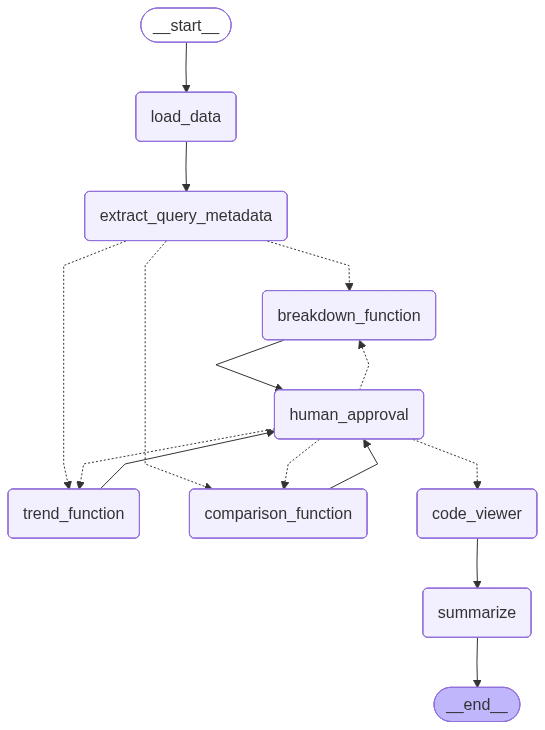

In [105]:
graph=StateGraph(vehRegState)

graph.add_node("load_data",load_data)
graph.add_node("extract_query_metadata",extract_query_metadata)
# graph.add_node("route_analysis",route_analysis)    # why because route analysis is not a node, but just a routing function, so why make a node out of it??
graph.add_node("trend_function",trend_function)
graph.add_node("comparison_function",comparison_function)
graph.add_node("breakdown_function",breakdown_function)
graph.add_node("human_approval",human_approval)
graph.add_node("code_viewer",code_viewer) # execute code after human says yes. . 
graph.add_node("summarize",summarize)

# add the edges
graph.add_edge(START,"load_data")
graph.add_edge("load_data","extract_query_metadata")
# graph.add_edge("extract_query_metadata","route_analysis")

graph.add_conditional_edges(
    "extract_query_metadata",
    route_analysis,
    {
        "trend_function": "trend_function",
        "comparison_function": "comparison_function",
        "breakdown_function": "breakdown_function"
    }
)

graph.add_edge("trend_function","human_approval")
# graph.add_edge("trend_function",END)

graph.add_edge("comparison_function","human_approval") 
# graph.add_edge("comparison_function",END)

graph.add_edge("breakdown_function","human_approval")
# graph.add_edge("breakdown_function",END)

graph.add_conditional_edges(
    "human_approval",
    approval_router,
    {
        "code_viewer":"code_viewer",
        "trend_function": "trend_function",
        "comparison_function": "comparison_function",
        "breakdown_function": "breakdown_function"
    }          
)


graph.add_edge("code_viewer","summarize")
graph.add_edge("summarize",END)

#compile the graph (autonomous)
graph.compile()


### Compare


Generated Code:

import pandas as pd
import matplotlib.pyplot as plt

# Filter data for Delhi and years between 2014 and 2024
delhi_data = df[(df['State'] == 'Delhi') & (df['Year'] >= 2014) & (df['Year'] <= 2024)]

# Since 'Type' column does not contain 'PETROL' or 'DIESEL', we assume 'Type' is used for comparison
petrol_data = delhi_data[delhi_data['Type'] == 'PETROL']
diesel_data = delhi_data[delhi_data['Type'] == 'DIESEL']

# Calculate sum of 'Count' for each year
petrol_counts = petrol_data.groupby('Year')['Count'].sum()
diesel_counts = diesel_data.groupby('Year')['Count'].sum()

# Create a line chart
plt.figure(figsize=(10,6))
plt.plot(petrol_counts.index, petrol_counts.values, label='PETROL')
plt.plot(diesel_counts.index, diesel_counts.values, label='DIESEL')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Comparison of PETROL and DIESEL in Delhi')
plt.legend()
plt.savefig('comparison_chart.png')

# Store comparison results in variable 'result' as a DataFrame
result = pd.DataF

{'message': [],
 'user_query': 'compare the PETROL and DIESEL across delhi from 2014 to 2024 using line chart.',
 'query_intent': 'comparison',
 'filters': {'state': ['delhi'],
  'fuel_type': ['PETROL', 'DIESEL'],
  'vehicle_category': None,
  'vehicle_class': None},
 'time_range': [2014, 2024],
 'data_loaded': True,
 'current_dataframe':           Year   State                              Rto_name  \
 0       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 1       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 2       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 3       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 4       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 ...        ...     ...                                   ...   
 393307  2014.0  Odisha  SUNDERGARH RTO - OR16( 08-NOV-2017 )   
 393308  2014.0  Odisha     TALCHER RTO - OR35( 25-DEC-2017 )   
 393309  2014.0  Odisha     TALCHER RTO - OR35( 25-DEC-2017 )   
 393310  2

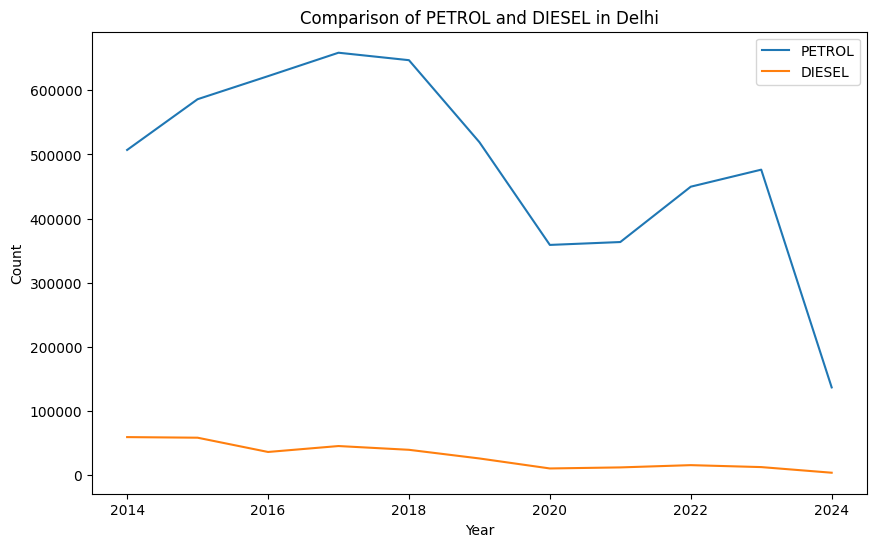

In [89]:
workflow=graph.compile()

initial_state={"user_query": "compare the PETROL and DIESEL across delhi from 2014 to 2024 using line chart."}
workflow.invoke(initial_state)

### Trend


Generated Code:

import pandas as pd
import matplotlib.pyplot as plt

# Filter the dataframe for Odisha and PETROL
odisha_petrol_df = df[(df['State'] == 'Odisha') & (df['Type'] == 'PETROL') & (df['Year'] >= 2014) & (df['Year'] <= 2024)]

# Group by Year and calculate the sum of Count
trend_df = odisha_petrol_df.groupby('Year')['Count'].sum().reset_index()

# Plot the trend
plt.figure(figsize=(10,6))
plt.plot(trend_df['Year'], trend_df['Count'], marker='o')
plt.title('Trend of PETROL across Odisha from 2014 to 2024')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Store the final result in variable 'result'
result = trend_df


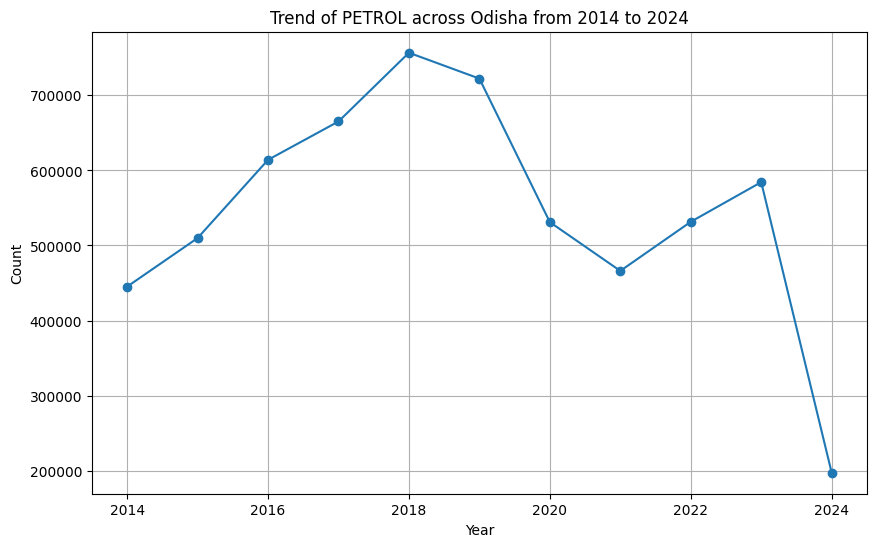

{'message': [],
 'user_query': 'Trend of PETROL across odisha from 2014 to 2024.',
 'query_intent': 'trend_analysis',
 'filters': {'state': ['odisha'],
  'fuel_type': ['PETROL'],
  'vehicle_category': None,
  'vehicle_class': None},
 'time_range': [2014, 2024],
 'data_loaded': True,
 'current_dataframe':           Year   State                              Rto_name  \
 0       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 1       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 2       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 3       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 4       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 ...        ...     ...                                   ...   
 393307  2014.0  Odisha  SUNDERGARH RTO - OR16( 08-NOV-2017 )   
 393308  2014.0  Odisha     TALCHER RTO - OR35( 25-DEC-2017 )   
 393309  2014.0  Odisha     TALCHER RTO - OR35( 25-DEC-2017 )   
 393310  2014.0  Odisha     TALCHER RTO - OR3

In [90]:
#compile the graph (autonomous)
workflow=graph.compile()

initial_state={"user_query": "Trend of PETROL across odisha from 2014 to 2024."}
workflow.invoke(initial_state)


### Breakdown


Generated Code:

import pandas as pd
import matplotlib.pyplot as plt

# Filter data for Bihar in 2021
bihar_2021 = df[(df['State'] == 'Bihar') & (df['Year'] == 2021)]

# Group by 'Type' and calculate count
result = bihar_2021.groupby('Type')['Count'].sum().to_dict()

# Calculate percentages
total_count = sum(result.values())
result = {k: (v / total_count) * 100 for k, v in result.items()}

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(list(result.keys()), list(result.values()))
plt.xlabel('Percentage')
plt.ylabel('Vehicle Type')
plt.title('Distribution of Vehicle Categories in Bihar for 2021')
plt.tight_layout()
plt.savefig('breakdown_chart.png')

print(result)

Generated Code:

import pandas as pd
import matplotlib.pyplot as plt

# Filter data for Bihar in 2021
bihar_2021 = df[(df['State'] == 'Bihar') & (df['Year'] == 2021)]

# Group by 'Type' and calculate count
result = bihar_2021.groupby('Type')['Count'].sum().to_dict()

# Calculate percentages
total_count = s

{'message': [],
 'user_query': 'Show the distribution of vehicle categories in Bihar for 2021.',
 'query_intent': 'breakdown',
 'filters': {'state': ['Bihar'],
  'fuel_type': [],
  'vehicle_category': None,
  'vehicle_class': None},
 'time_range': [2021],
 'data_loaded': True,
 'current_dataframe':           Year   State                              Rto_name  \
 0       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 1       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 2       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 3       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 4       2024.0   Bihar          ARARIA - BR38( 30-JAN-2018 )   
 ...        ...     ...                                   ...   
 393307  2014.0  Odisha  SUNDERGARH RTO - OR16( 08-NOV-2017 )   
 393308  2014.0  Odisha     TALCHER RTO - OR35( 25-DEC-2017 )   
 393309  2014.0  Odisha     TALCHER RTO - OR35( 25-DEC-2017 )   
 393310  2014.0  Odisha     TALCHER RTO - OR35( 25-

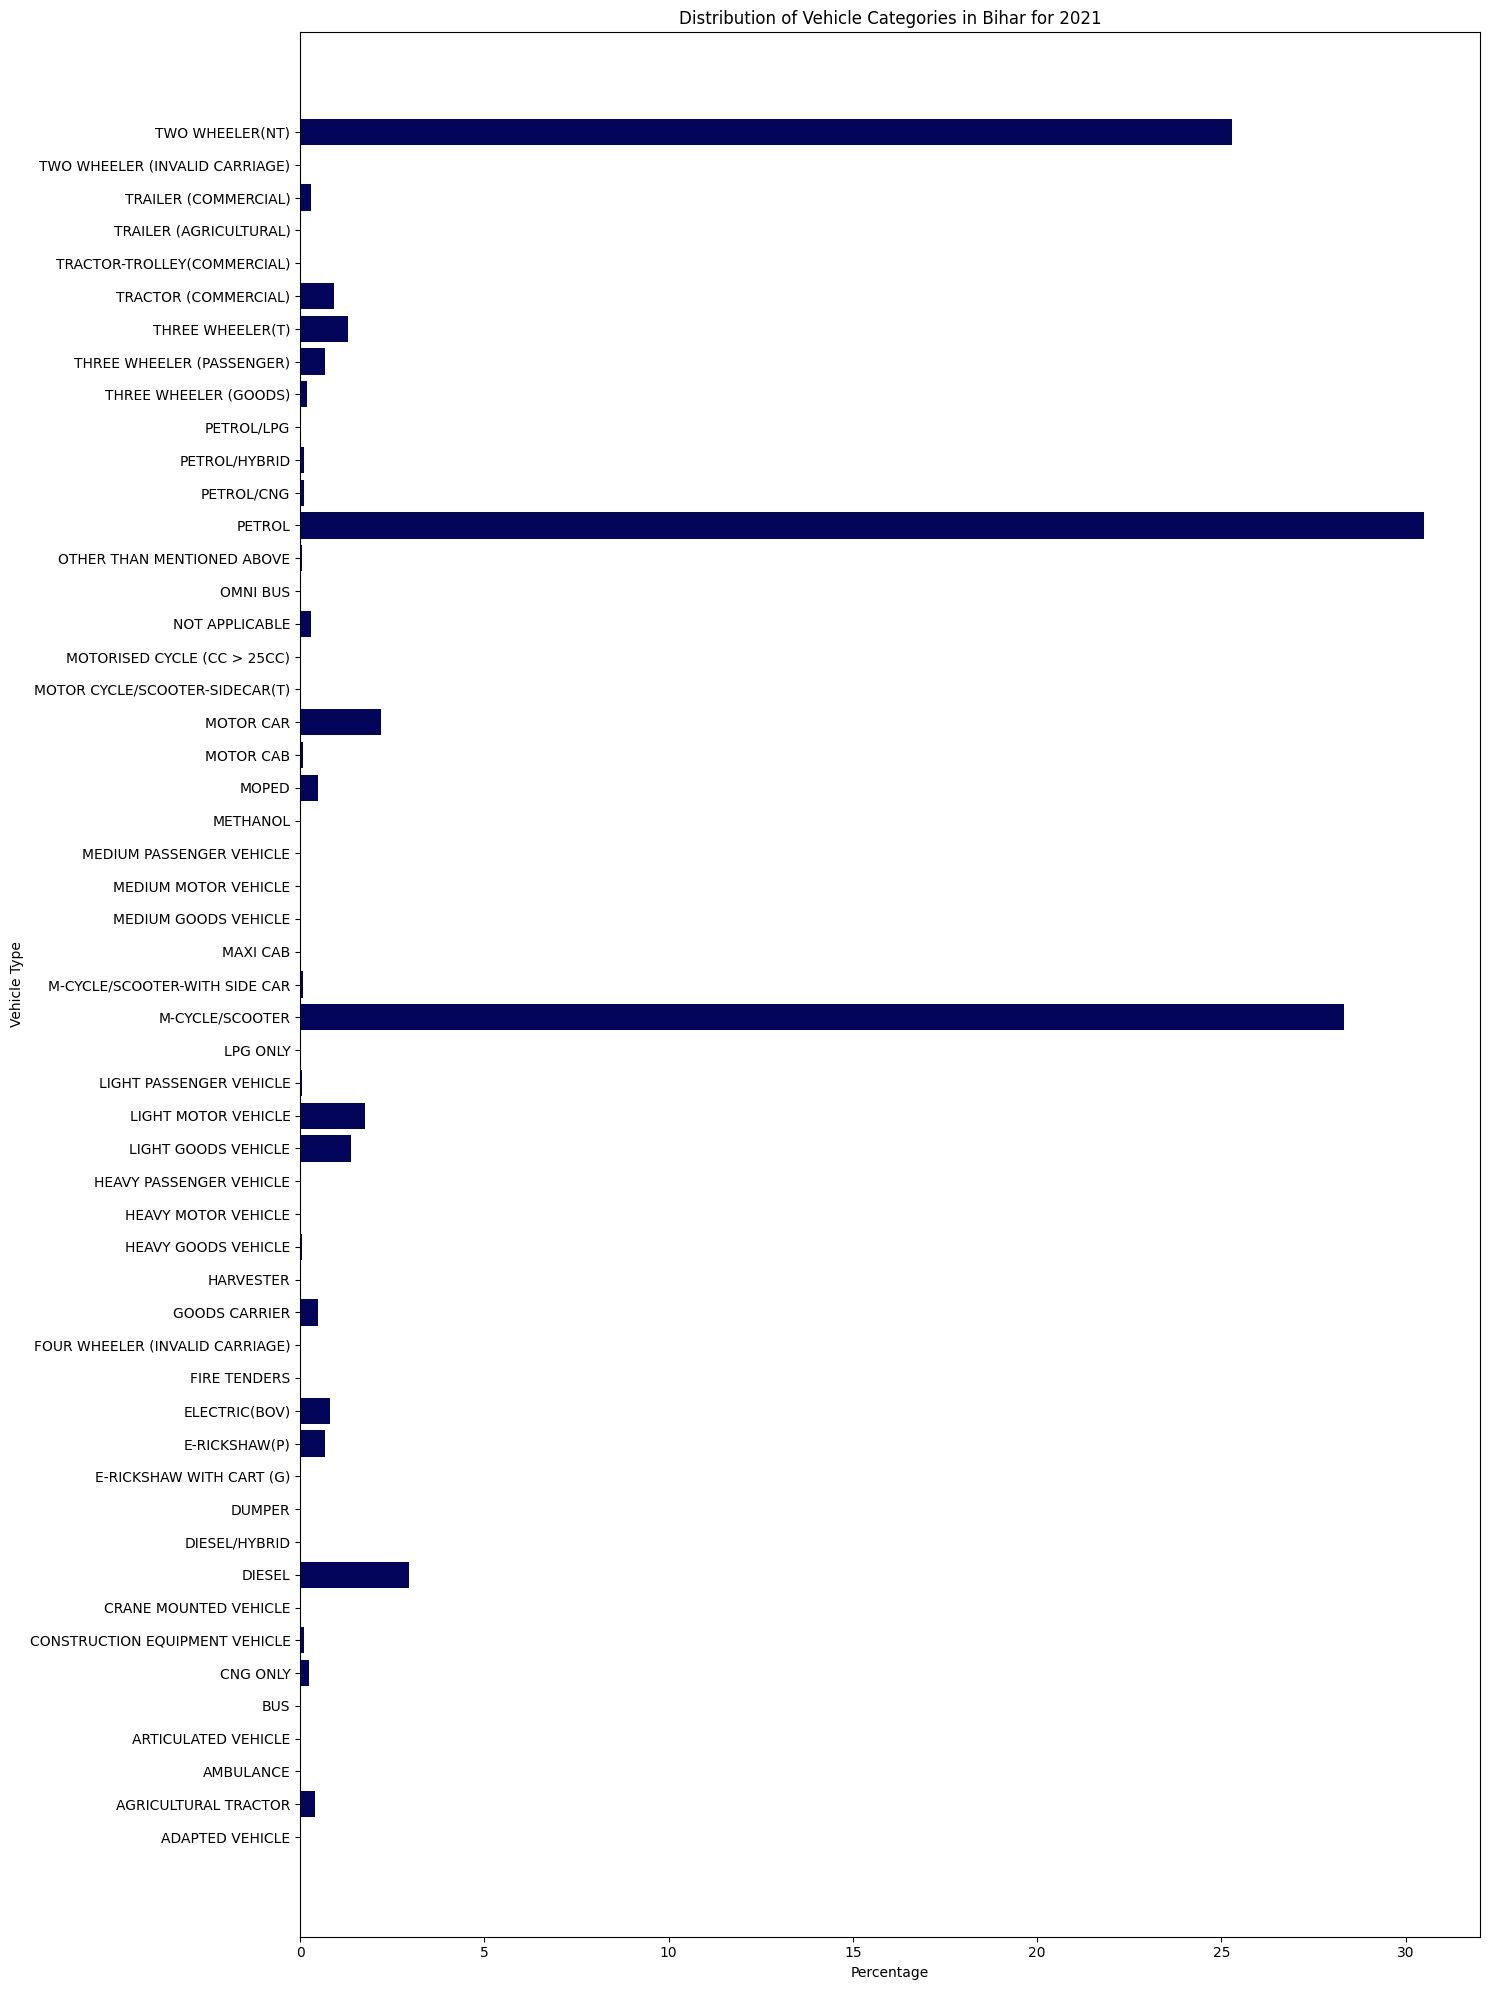

In [107]:
workflow=graph.compile()

initial_state={"user_query": "Show the distribution of vehicle categories in Bihar for 2021."}
workflow.invoke(initial_state)


In [ ]:
'''
CHANGES TO PLAY WITH. . . . . . . .

- can change basemodal output schema to get various types of query.
- weak LLM
'''

In [ ]:
''' If u want to learn and add interuppt u manually need to run it like this, but if streamlit/ chatbot UI then manually writing not needed
because simple enter in the chat comes (yes / no)

right now, i will use input() funtion. . . '''

#### for approve

In [ ]:

# workflow.invoke(
#     Command(
#         resume={
#             "status": "approved"
#         }
#     ),
#     config=config
# )

#### for reject

In [ ]:
# workflow.invoke(
#     Command(
#         resume={
#             "status": "rejected",
#             "feedback": "Use exact ELECTRIC(BOV)"
#         }
#     ),
#     config=config
# )

## Thank You !!!